# Customer Churn Prediction

This project aims to predict whether a customer will churn (leave) or stay using machine learning techniques.

###  Objective

The goal of this project is to analyze customer behavior and build a model to predict customer churn. This helps businesses take proactive actions to retain customers.

###  Dataset

The dataset contains telecom customer information including usage patterns, billing details, and customer service interactions.

Target Variable:
- **Churn** → Indicates whether a customer leaves (1) or stays (0)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

### Data Understanding

Key features in the dataset:
- AccountWeeks: Duration of customer relationship
- ContractRenewal: Whether contract is renewed
- DataPlan: Availability of data plan
- DataUsage: Internet usage
- CustServCalls: Number of customer service calls
- MonthlyCharge: Monthly bill amount
- OverageFee: Extra charges
- RoamMins: Roaming usage

In [2]:
data = pd.read_csv("telecom_churn.csv")

### Data Preprocessing

- Checked for missing values
- Ensured all columns are in numeric format
- Split data into features (X) and target (y)

In [3]:
data.head(10)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
5,0,118,0,0,0.00,0,223.4,98,57.0,11.03,6.3
6,0,121,1,1,2.03,3,218.2,88,87.3,17.43,7.5
7,0,147,0,0,0.00,0,157.0,79,36.0,5.16,7.1
8,0,117,1,0,0.19,1,184.5,97,63.9,17.58,8.7
9,0,141,0,1,3.02,0,258.6,84,93.2,11.10,11.2


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [5]:
data.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [6]:
x = data.drop("Churn",axis=1)
y = data["Churn"]

### Exploratory Data Analysis

Performed data visualization to understand patterns:
- Distribution of churned vs retained customers
- Correlation between features using heatmap

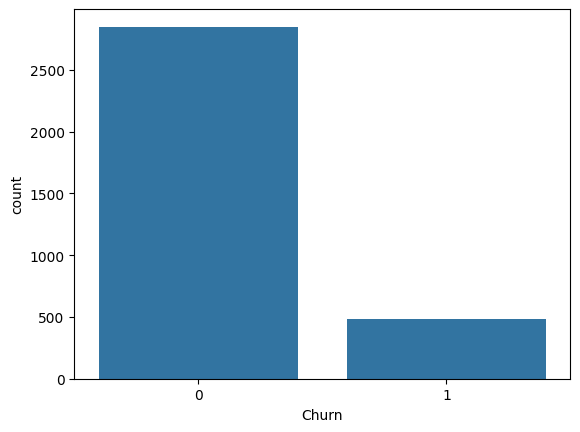

In [7]:
# churn count
sns.countplot(x='Churn', data=data)
plt.show()


### Churn Distribution

The dataset shows that the number of customers who did not churn is significantly higher than those who churned.

This indicates a class imbalance problem, where the majority of customers stay while a smaller portion leaves the company.

>Since the dataset is imbalanced, accuracy alone may not be a reliable metric. Therefore, additional evaluation metrics like precision, recall, and F1-score are used.

In [8]:
data['Churn'].value_counts(normalize=True)

Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64

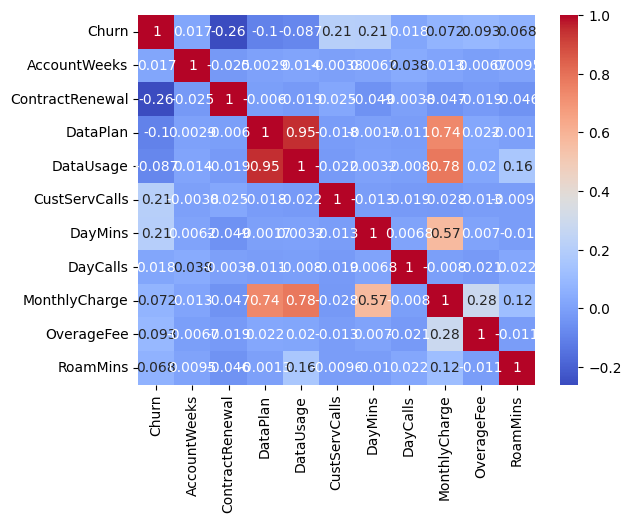

In [9]:
# correlation
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Correlation Analysis

- Customer service calls show positive correlation with churn
- Contract renewal has negative correlation with churn
- Strong relationships exist between data usage and monthly charges
- Churn depends on multiple factors rather than a single feature

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.25, random_state=67, stratify=y)

### Model Building

Two models were used:
- Logistic Regression
- Random Forest Classifier

These models were trained to predict customer churn.

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr_cv = cross_val_score(lr, x_train, y_train, cv=5)

print("LR CV Score:", lr_cv.mean())

LR CV Score: 0.8607486973947897


In [12]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_cv = cross_val_score(rf, x_train, y_train, cv=5)

print("RF CV Score:", rf_cv.mean())

RF CV Score: 0.9331743486973949


In [13]:
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
lr_pred = lr.predict(x_test)
rf_pred = rf.predict(x_test)

In [15]:
print("Logistic Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Logistic Accuracy: 0.8597122302158273
Random Forest Accuracy: 0.9268585131894485
[[702  11]
 [ 50  71]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       713
           1       0.87      0.59      0.70       121

    accuracy                           0.93       834
   macro avg       0.90      0.79      0.83       834
weighted avg       0.92      0.93      0.92       834



### Cross Validation

Cross-validation was used to evaluate the model more reliably by splitting the training data into multiple folds. This helps reduce overfitting and provides a more robust performance estimate.

#### Model Comparison using Cross Validation

Cross-validation results show that Random Forest performs better than Logistic Regression, indicating its ability to capture complex relationships in the data.

### Model Evaluation

- Compared models using accuracy score
- Used confusion matrix and classification report for detailed evaluation
- Random Forest performed better due to handling complex relationships

The model performs well overall but has lower recall for churn cases, meaning some churn customers are not correctly identified. This highlights the challenge of predicting minority class instances.

In [16]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(x_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8760330578512396


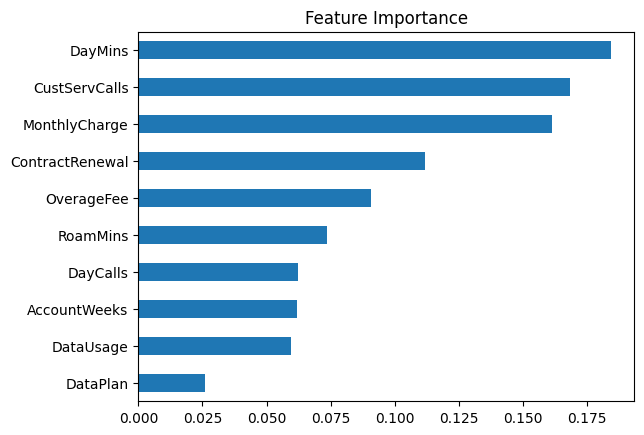

In [17]:
importances = rf.feature_importances_
features = x.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

#### Feature Importance

Feature importance analysis showed that:
- Customer service calls
- Monthly charges
- Contract renewal

are key factors influencing churn.

### Final Insights

- The dataset is imbalanced, with most customers not churning
- Customers with higher customer service calls are more likely to churn
- Contract renewal significantly reduces churn probability
- Higher monthly charges and usage are associated with increased churn risk
- Churn is influenced by multiple factors rather than a single feature

### Conclusion

This project successfully built a machine learning model to predict customer churn using telecom data. 

Exploratory Data Analysis revealed key patterns in customer behavior, while model comparison showed that Random Forest performed better due to its ability to capture complex relationships.

The analysis highlights that customer service experience, pricing, and contract renewal are critical factors affecting customer retention.

Machine learning can help businesses identify at-risk customers and take proactive steps to reduce churn.

Cross-validation was used to ensure model stability and reduce overfitting.